In [291]:
# main.py
# ─────────────────────────────────────────────────────────────────────────────
# Orchestrates the full solenoid design-space study.
#
#   Run in Jupyter/IPython to utilize interactive widgets.
# ─────────────────────────────────────────────────────────────────────────────
%matplotlib widget

import importlib
import numpy as np

# Hot-reload local modules to ensure we always have the latest code
import solenoid_lib
importlib.reload(solenoid_lib)

import config
importlib.reload(config)

import grid
importlib.reload(grid)

import io_grids
importlib.reload(io_grids)

import plots_thickness
importlib.reload(plots_thickness)

import plots_area
importlib.reload(plots_area)


# Define the lengths (in meters) to iterate over
LENGTHS_M =  [9.0]  

def main():
    all_grids = {}
    
    for L in LENGTHS_M:
        print(f"\n=== Solenoid Length = {L*1e3:.0f} mm ===")
        
        # 1. Update the physics library with the current length
        solenoid_lib.solenoid_length = L
        label = f"L{int(L*1e3)}mm"
        
        # 2. Build the meshgrids based on Thickness
        a_grids = grid.build_thickness_grid()
        
        # 3. Save the results to the newly formatted CSV
        csv_filename = f"thickness_grids_{label}.csv"
        io_grids.save_grids_long(a_grids, csv_filename, solenoid_length=L)
        
        # 4. Generate all the requested contour plots
        #plots_thickness.plot_all(a_grids, label=label, solenoid_length_m=L)
        
        # Store for return
        all_grids[L] = a_grids
        
    return all_grids


if __name__ == "__main__":
    # Run the main loop
    all_grids = main()



=== Solenoid Length = 9000 mm ===
  25000/25000  (100%)
2-D meshgrid (Th-scan) computed.
  Valid cells     : 25000 / 25000
  Converged cells : 25000 / 25000
  Ri              : 10.0 – 1500.0 mm
  Th              : 2.0 – 350.0
  f_sc (%)        : 9.0 – 100.0
  B0              : 1.483 – 93.909 T
  Stress          : 4.4 – 750.0 MPa
Saved raw grids -> thickness_grids_L9000mm.csv  (25000 cells)


In [ ]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
import glob

# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)

# -------------------------------------------------------------------------
# 2. HELPER FUNCTIONS (Interactivity & Regridding)
# -------------------------------------------------------------------------
def setup_grid_annotation(fig, scatters, data_dfs, active_axes):
    annots = []
    for ax in active_axes:
        annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=8, zorder=10)
        annot.set_visible(False)
        annots.append(annot)

    def on_pick(event):
        # Hide all annotations first
        for ann in annots:
            ann.set_visible(False)
            
        # Find which scatter point was clicked/hovered
        for i, scat in enumerate(scatters):
            if event.artist == scat:
                ind = event.ind[0]
                row = data_dfs[i].iloc[ind]
                x, y = event.artist.get_offsets()[ind]
                
                text = (f"L={row['solenoid_length_m']:.1f} m\n"
                        f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                        f"B0={row['b0']:.2f} T\n"
                        f"Total SC={row['length_sc_km']:.1f} km\n"
                        f"Pancake={row['pancake_length_m']:.1f} m\n"
                        f"Scan={row['scan']:.1f} yrs")
                
                annots[i].xy = (x, y)
                annots[i].set_text(text)
                annots[i].set_visible(True)
                fig.canvas.draw_idle()
                break

    fig.canvas.mpl_connect("pick_event", on_pick)


def _regrid(x, y, z, nx=400, ny=400):
    xf, yf, zf = np.asarray(x).flatten(), np.asarray(y).flatten(), np.asarray(z).flatten()
    mask = np.isfinite(xf) & np.isfinite(yf) & np.isfinite(zf)
    
    if not mask.any():
        xi = np.linspace(np.nanmin(xf) if len(xf) else 0, np.nanmax(xf) if len(xf) else 1, nx)
        yi = np.linspace(np.nanmin(yf) if len(yf) else 0, np.nanmax(yf) if len(yf) else 1, ny)
        xi2d, yi2d = np.meshgrid(xi, yi)
        return xi2d, yi2d, np.full_like(xi2d, np.nan)
        
    xi = np.linspace(np.nanmin(xf[mask]), np.nanmax(xf[mask]), nx)
    yi = np.linspace(np.nanmin(yf[mask]), np.nanmax(yf[mask]), ny)
    xi2d, yi2d = np.meshgrid(xi, yi)
    zi2d = griddata((xf[mask], yf[mask]), zf[mask], (xi2d, yi2d), method="linear")
    return xi2d, yi2d, zi2d


def draw_contours(ax, x, y, df, plot_type):
    scan_limit = 20.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 

    field_line_levels = [5, 10 ,15, 25, 30, 40, 50, 55, 60] 

    th_line_levels = [50, 100, 150, 200, 250, 300, 350, 400] 

    # 1. Scan time background map
    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)
    
    # 2. Magnetic Field (B0)
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.5, levels=field_line_levels, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0f T', fontsize=8, colors='black')

    # 3. Scan Time (Lines)
    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.2, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0f yr', fontsize=8, colors='steelblue')

    # 4. Hoop Stress
    stress_levels = 10 if plot_type == 3 else 3
    _, _, zi_stress = _regrid(x, y, df['stress'])
    if np.isfinite(zi_stress).any():
        iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.2, levels=stress_levels, zorder=3)
        ax.clabel(iso_stress, inline=True, fmt='%.0f MPa', fontsize=8, colors='crimson')

    # 5. Thickness (Only for Graphs 2 and 3)
    if plot_type in [2, 3]:
        _, _, zi_th = _regrid(x, y, df['th'] * 1000)
        if np.isfinite(zi_th).any():
            iso_th = ax.contour(xi, yi, zi_th, colors='purple', linestyles='dotted', linewidths=1.2, levels=th_line_levels, zorder=3)
            ax.clabel(iso_th, inline=True, fmt='%.0f mm', fontsize=8, colors='purple')
            
    return cntr

# -------------------------------------------------------------------------
# 3. MAIN PLOTTING FUNCTION
# -------------------------------------------------------------------------
def plot_selected_length(target_length_m, df_full):
    # Filter the DataFrame for the selected length
    df_sub = df_full[df_full['solenoid_length_m'] == target_length_m].reset_index(drop=True)
    
    if df_sub.empty:
        print(f"No data found for L = {target_length_m} m.")
        print(f"Available lengths are: {sorted(df_full['solenoid_length_m'].unique())}")
        return
        
    # Create the 1x3 figure
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
    fig.suptitle(f'Detailed Parameter Maps for Solenoid Length L = {target_length_m*1000:.0f} mm', fontsize=16, fontweight='bold', y=1)
    
    x_mm = df_sub['ri'] * 1000
    scats = []
    
    # Legend Elements
    leg1 = [
        Line2D([0], [0], color='black', lw=1.5, label='B₀ (T)'),
        Line2D([0], [0], color='steelblue', lw=1.5, linestyle='--', label='Scan time (yr)'),
        Line2D([0], [0], color='crimson', lw=1.5, linestyle='-.', label='Hoop stress (MPa)')
    ]
    leg23 = leg1 + [Line2D([0], [0], color='purple', lw=1.5, linestyle=':', label='Thickness (mm)')]

    # Graph 1: Coil Thickness
    ax1 = axes[0]
    y1_mm = df_sub['th'] * 1000
    cntr1 = draw_contours(ax1, x_mm, y1_mm, df_sub, plot_type=1)
    fig.colorbar(cntr1, ax=ax1, label='Scan time (yr)')
    
    ax1.set_xlabel('Inner radius Ri (mm)')
    ax1.set_ylabel('Coil thickness (mm)')
    ax1.set_title('1. Coil Thickness vs Inner Radius')
    ax1.legend(handles=leg1, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax1.scatter(x_mm, y1_mm, color='white', alpha=0.0, picker=5, zorder=5))
    ax1.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax1.set_ylim(0, 400)   # Set y-axis limit to 400 mm

    # Graph 2: Pancake Length
    ax2 = axes[1]
    y2_m = df_sub['pancake_length_m']
    cntr2 = draw_contours(ax2, x_mm, y2_m, df_sub, plot_type=2)
    fig.colorbar(cntr2, ax=ax2, label='Scan time (yr)')
    
    ax2.set_xlabel('Inner radius Ri (mm)')
    ax2.set_ylabel('REBCO length per pancake (m)')
    ax2.set_title('2. Pancake Length vs Inner Radius')
    ax2.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax2.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax2.scatter(x_mm, y2_m, color='white', alpha=0.0, picker=5, zorder=5))
    ax2.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax2.set_ylim(0, 2500)   # Set y-axis limit to 2500 m


    # Graph 3: Total REBCO Length
    ax3 = axes[2]
    y3_km = df_sub['length_sc_km']
    cntr3 = draw_contours(ax3, x_mm, y3_km, df_sub, plot_type=3)
    fig.colorbar(cntr3, ax=ax3, label='Scan time (yr)')
    
    ax3.set_xlabel('Inner radius Ri (mm)')
    ax3.set_ylabel('Total REBCO length (km)')
    ax3.set_title('3. Total REBCO Length vs Inner Radius')
    ax3.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax3.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax3.scatter(x_mm, y3_km, color='white', alpha=0.0, picker=5, zorder=5))
    ax3.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax3.set_ylim(0, 3000)   # Set y-axis limit to 3000 km

    # Connect interactivity and adjust layout
    setup_grid_annotation(fig, scats, [df_sub, df_sub, df_sub], axes)
    fig.tight_layout()
    plt.show()

# -------------------------------------------------------------------------
# 4. EXECUTE PLOT
# Change the length below to map a different target length (e.g. 5.0, 6.0)
# -------------------------------------------------------------------------
selected_length = 5.0 
plot_selected_length(selected_length, df_all)

In [ ]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
import glob

# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)

# -------------------------------------------------------------------------
# 2. HELPER FUNCTIONS
# -------------------------------------------------------------------------
def setup_grid_annotation(fig, scatters, data_dfs, active_axes):
    annots = []
    for ax in active_axes:
        annot = ax.annotate("", xy=(0, 0), xytext=(10, 10), textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=7, zorder=10)
        annot.set_visible(False)
        annots.append(annot)

    def on_pick(event):
        for ann in annots:
            ann.set_visible(False)
            
        for i, scat in enumerate(scatters):
            if event.artist == scat:
                ind = event.ind[0]
                row = data_dfs[i].iloc[ind]
                x, y = event.artist.get_offsets()[ind]
                
                text = (f"L={row['solenoid_length_m']:.1f} m\n"
                        f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                        f"B0={row['b0']:.2f} T\n"
                        f"Total SC={row['length_sc_km']:.1f} km\n"
                        f"Pancake={row['pancake_length_m']:.1f} m\n"
                        f"Scan={row['scan']:.1f} yrs")
                
                annots[i].xy = (x, y)
                annots[i].set_text(text)
                annots[i].set_visible(True)
                fig.canvas.draw_idle()
                break

    fig.canvas.mpl_connect("pick_event", on_pick)


def _regrid(x, y, z, nx=400, ny=400):
    xf, yf, zf = np.asarray(x).flatten(), np.asarray(y).flatten(), np.asarray(z).flatten()
    mask = np.isfinite(xf) & np.isfinite(yf) & np.isfinite(zf)
    
    if not mask.any():
        xi = np.linspace(np.nanmin(xf) if len(xf) else 0, np.nanmax(xf) if len(xf) else 1, nx)
        yi = np.linspace(np.nanmin(yf) if len(yf) else 0, np.nanmax(yf) if len(yf) else 1, ny)
        xi2d, yi2d = np.meshgrid(xi, yi)
        return xi2d, yi2d, np.full_like(xi2d, np.nan)
        
    xi = np.linspace(np.nanmin(xf[mask]), np.nanmax(xf[mask]), nx)
    yi = np.linspace(np.nanmin(yf[mask]), np.nanmax(yf[mask]), ny)
    xi2d, yi2d = np.meshgrid(xi, yi)
    zi2d = griddata((xf[mask], yf[mask]), zf[mask], (xi2d, yi2d), method="linear")
    return xi2d, yi2d, zi2d


def draw_contours_small(ax, x, y, df):
    scan_limit = 20.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 

    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)
    
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.0, levels=10, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0fT', fontsize=6, colors='black')

    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.0, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0fyr', fontsize=6, colors='steelblue')

    _, _, zi_stress = _regrid(x, y, df['stress'])
    if np.isfinite(zi_stress).any():
        iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.0, levels=3, zorder=3)
        ax.clabel(iso_stress, inline=True, fmt='%.0fMPa', fontsize=6, colors='crimson')
            
    return cntr


def draw_contours_small_2_3(ax, x, y, df, plot_type):
    scan_limit = 20.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 

    field_line_levels = [5, 10 ,15, 25, 30, 40, 50, 55, 60] 

    th_line_levels = [50, 100, 150, 200, 250, 300, 350, 400]

    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)
    
    # B0
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.0, levels=field_line_levels, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0fT', fontsize=6, colors='black')

    # Scan Time
    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.0, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0fyr', fontsize=6, colors='steelblue')

    # Hoop Stress (Graph 3 often needs more levels to show detail)
    stress_levels = 10 if plot_type == 3 else 3
    _, _, zi_stress = _regrid(x, y, df['stress'])
    if np.isfinite(zi_stress).any():
        iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.0, levels=stress_levels, zorder=3)
        ax.clabel(iso_stress, inline=True, fmt='%.0fMPa', fontsize=6, colors='crimson')

    # Thickness Lines (Purple dotted)
    _, _, zi_th = _regrid(x, y, df['th'] * 1000)
    if np.isfinite(zi_th).any():
        iso_th = ax.contour(xi, yi, zi_th, colors='purple', linestyles='dotted', linewidths=1.0, levels=th_line_levels, zorder=3)
        ax.clabel(iso_th, inline=True, fmt='%.0fmm', fontsize=6, colors='purple')
            
    return cntr

# Legend for Graphs 2 and 3
leg23_elements = [
    Line2D([0], [0], color='black', lw=1.2, label='B₀'),
    Line2D([0], [0], color='steelblue', lw=1.2, linestyle='--', label='Scan'),
    Line2D([0], [0], color='crimson', lw=1.2, linestyle='-.', label='Stress'),
    Line2D([0], [0], color='purple', lw=1.2, linestyle=':', label='Thickness') 
]

unique_lengths = sorted(df_all['solenoid_length_m'].unique())



# -------------------------------------------------------------------------
# 3. SET UP GRID AND PLOT
# -------------------------------------------------------------------------
unique_lengths = sorted(df_all['solenoid_length_m'].unique())

# Smaller figure size
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False)
fig.suptitle('Coil Thickness vs Inner Radius', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
scats = []
dfs = []
active_axes = []

# Compact legend elements
leg1_elements = [
    Line2D([0], [0], color='black', lw=1.2, label='B₀'),
    Line2D([0], [0], color='steelblue', lw=1.2, linestyle='--', label='Scan'),
    Line2D([0], [0], color='crimson', lw=1.2, linestyle='-.', label='Stress'),
    Line2D([0], [0], color='purple', lw=1.2, linestyle=':', label='SC Len') 
]

for i, L in enumerate(unique_lengths):
    if i >= 10:
        break
        
    df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
    ax = axes_flat[i]
    
    x_mm = df_sub['ri'] * 1000
    y1_mm = df_sub['th'] * 1000
    
    cntr = draw_contours_small(ax, x_mm, y1_mm, df_sub)
    
    # Add a thin colorbar with smaller font
    cbar = fig.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)
    if i % 5 == 4: # Only label the colorbars on the far right to save space
        cbar.set_label('Scan time (yr)', size=8)
    
    if i >= 5: # Only label x-axis on bottom row
        ax.set_xlabel('Ri (mm)', fontsize=8)
    if i % 5 == 0:
        ax.set_ylabel('Coil th (mm)', fontsize=8)
        
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
    ax.legend(handles=leg1_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
    scat = ax.scatter(x_mm, y1_mm, color='white', alpha=0.0, picker=5, zorder=5)
    
    scats.append(scat)
    dfs.append(df_sub)
    active_axes.append(ax)

# Hide any blank subplots
for j in range(len(active_axes), len(axes_flat)):
    axes_flat[j].set_visible(False)

setup_grid_annotation(fig, scats, dfs, active_axes)

fig.tight_layout()
plt.show()

# =========================================================================
# FIGURE 2: PANCAKE LENGTH VS INNER RADIUS (Shared Y-Axis)
# =========================================================================
# Find global min and max for pancake length to set consistent limits
y2_min, y2_max = df_all['pancake_length_m'].min(), 3000

# Add sharey=True here
fig2, axes2 = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False, sharey=True)
fig2.suptitle('2. Pancake Length vs Inner Radius', fontsize=14, fontweight='bold')

axes2_flat = axes2.flatten()
scats2, dfs2, active_axes2 = [], [], []

for i, L in enumerate(unique_lengths):
    if i >= 10: break
    df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
    ax = axes2_flat[i]
    x_mm = df_sub['ri'] * 1000
    y2_m = df_sub['pancake_length_m']
    
    cntr = draw_contours_small_2_3(ax, x_mm, y2_m, df_sub, plot_type=2)
    
    cbar = fig2.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)
    if i % 5 == 4: cbar.set_label('Scan time (yr)', size=8)
    
    if i >= 5: ax.set_xlabel('Ri (mm)', fontsize=8)
    if i % 5 == 0: ax.set_ylabel('Pancake len (m)', fontsize=8)
        
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
    # Set the shared limits explicitly
    ax.set_ylim(y2_min - y2_pad, y2_max + y2_pad)
    
    ax.legend(handles=leg23_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
    scat = ax.scatter(x_mm, y2_m, color='white', alpha=0.0, picker=5, zorder=5)
    scats2.append(scat); dfs2.append(df_sub); active_axes2.append(ax)

for j in range(len(active_axes2), len(axes2_flat)): axes2_flat[j].set_visible(False)
setup_grid_annotation(fig2, scats2, dfs2, active_axes2)
fig2.tight_layout()


# =========================================================================
# FIGURE 3: TOTAL REBCO LENGTH VS INNER RADIUS (Shared Y-Axis)
# =========================================================================
# Find global min and max for total length
y3_min, y3_max = df_all['length_sc_km'].min(), 1500
y3_pad = 0

# Add sharey=True here
fig3, axes3 = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False, sharey=True)
fig3.suptitle('3. Total REBCO Length vs Inner Radius', fontsize=14, fontweight='bold')

axes3_flat = axes3.flatten()
scats3, dfs3, active_axes3 = [], [], []

for i, L in enumerate(unique_lengths):
    if i >= 10: break
    df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
    ax = axes3_flat[i]
    x_mm = df_sub['ri'] * 1000
    y3_km = df_sub['length_sc_km']
    
    cntr = draw_contours_small_2_3(ax, x_mm, y3_km, df_sub, plot_type=3)
    
    cbar = fig3.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)
    if i % 5 == 4: cbar.set_label('Scan time (yr)', size=8)
    
    if i >= 5: ax.set_xlabel('Ri (mm)', fontsize=8)
    if i % 5 == 0: ax.set_ylabel('Total SC len (km)', fontsize=8)
        
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
    # Set the shared limits explicitly
    ax.set_ylim(y3_min - y3_pad, y3_max + y3_pad)
    
    ax.legend(handles=leg23_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
    scat = ax.scatter(x_mm, y3_km, color='white', alpha=0.0, picker=5, zorder=5)
    scats3.append(scat); dfs3.append(df_sub); active_axes3.append(ax)

for j in range(len(active_axes3), len(axes3_flat)): axes3_flat[j].set_visible(False)
setup_grid_annotation(fig3, scats3, dfs3, active_axes3)
fig3.tight_layout()

plt.show()

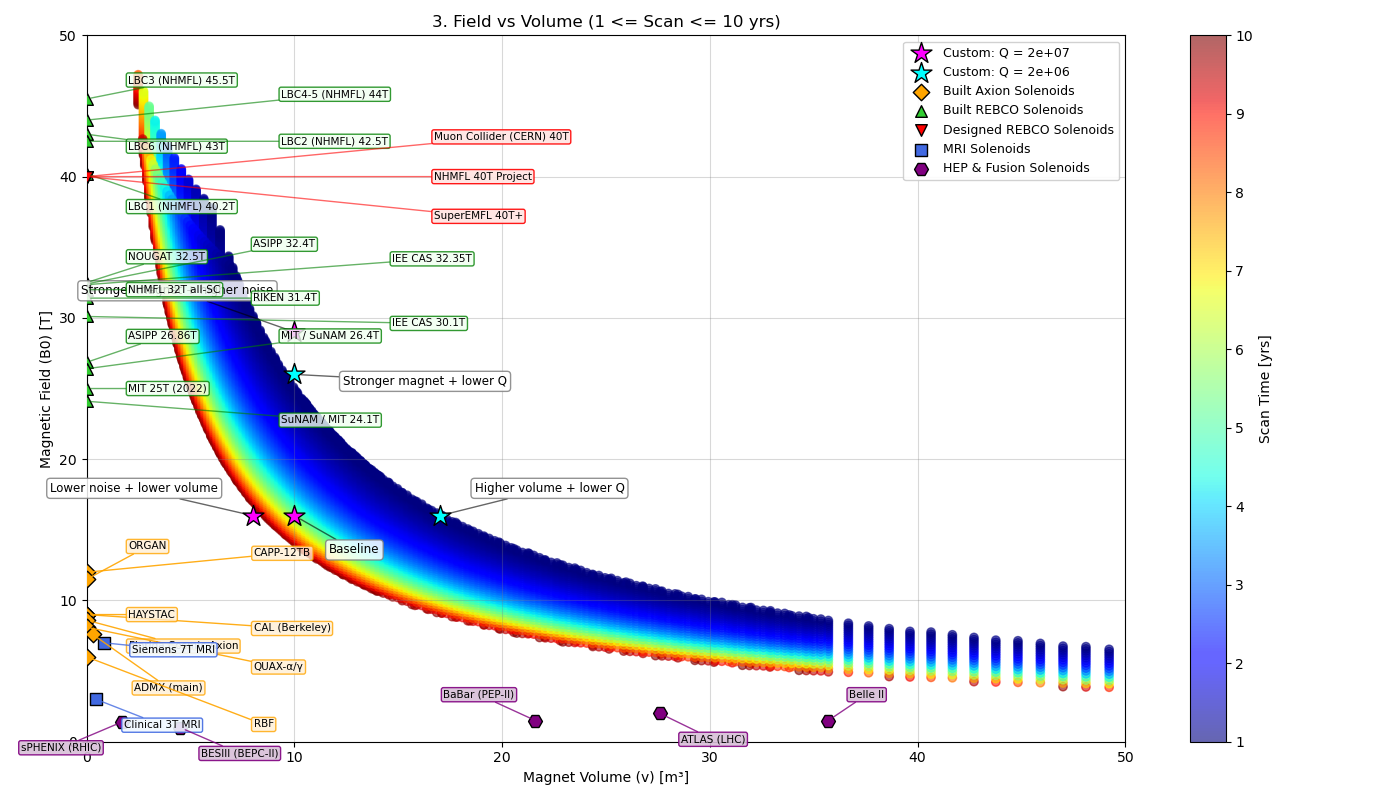

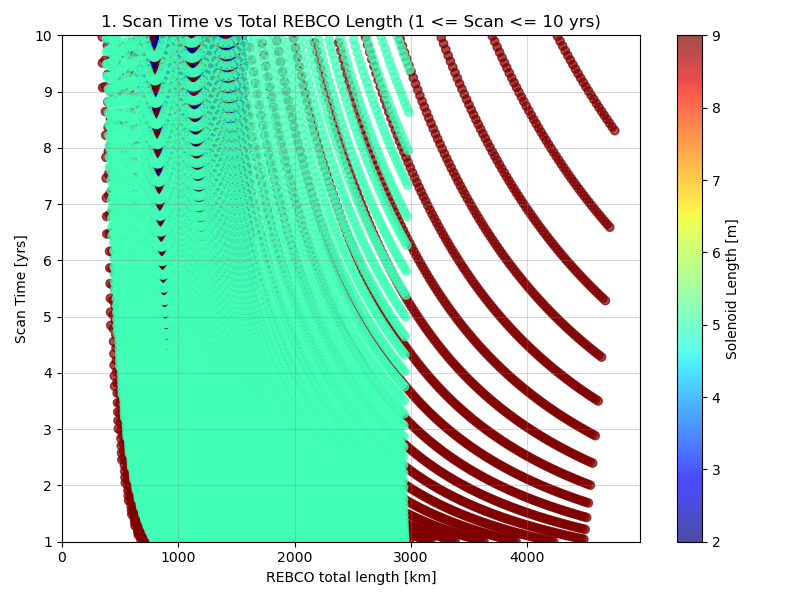

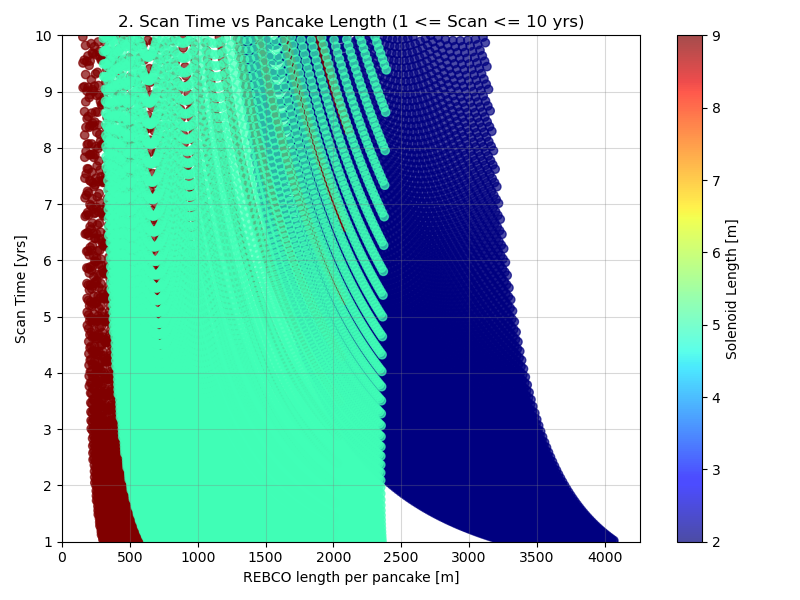

In [292]:
# -------------------------------------------------------------------------
# GLOBAL SCATTER PLOTS (Figs 1, 2, 3)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt


# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)


def setup_single_annotation(fig, ax, scatter_obj, data_df):
    annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                        bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=8, zorder=10)
    annot.set_visible(False)

    def on_pick(event):
        if event.artist != scatter_obj:
            return
            
        ind = event.ind[0]
        row = data_df.iloc[ind]

        x, y = event.artist.get_offsets()[ind]
        
        text = (f"L={row['solenoid_length_m']:.1f} m\n"
                f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                f"B0={row['b0']:.2f} T\n"
                f"Total SC={row['length_sc_km']:.1f} km\n"
                f"Pancake SC={row['pancake_length_m']:.1f} m\n"
                f"Scan={row['scan']:.1f} yrs\n"
                f"Vol={row.get('v', 0):.2f}")

        annot.xy = (x, y)
        annot.set_text(text)
        annot.set_visible(True)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect("pick_event", on_pick)


# --- 1. FILTERING & AXIS CONTROLS ---

# Filter out magnets with a scan time outside the 1 to 10 year range
min_scan_years = 1.0
max_scan_years = 10.0
df_filtered = df_all[(df_all['scan'] >= min_scan_years) & (df_all['scan'] <= max_scan_years)].reset_index(drop=True)

# Axis limits for Graph 1 & 2
g1_xlim = (0, None)
g1_ylim = (min_scan_years, max_scan_years)
g2_xlim = (0, None)
g2_ylim = (min_scan_years, max_scan_years)

# Axis limits for Graph 3
g3_xlim = (0, 50) 
g3_ylim = (0, 50) 


# -------------------------------------------------------------------------
# 1. Scan time vs REBCO total length 
# -------------------------------------------------------------------------

fig1, ax1 = plt.subplots(figsize=(8, 6))
scat1 = ax1.scatter(df_filtered['length_sc_km'], df_filtered['scan'], 
                    c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, picker=5)
fig1.colorbar(scat1, ax=ax1, label='Solenoid Length [m]')
ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(g1_xlim)
ax1.set_ylim(g1_ylim)
ax1.set_title('1. Scan Time vs Total REBCO Length (1 <= Scan <= 10 yrs)')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3)
setup_single_annotation(fig1, ax1, scat1, df_filtered)
fig1.tight_layout()

# -------------------------------------------------------------------------
# 2. Scan time vs REBCO length per pancake 
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6))
scat2 = ax2.scatter(df_filtered['pancake_length_m'], df_filtered['scan'], 
                    c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, picker=5)
fig2.colorbar(scat2, ax=ax2, label='Solenoid Length [m]')
ax2.set_xlabel('REBCO length per pancake [m]')
ax2.set_ylabel('Scan Time [yrs]')
ax2.set_xlim(g2_xlim)
ax2.set_ylim(g2_ylim)
ax2.set_title('2. Scan Time vs Pancake Length (1 <= Scan <= 10 yrs)')
ax2.grid(True, linestyle='-', color='gray', alpha=0.3)
setup_single_annotation(fig2, ax2, scat2, df_filtered)
fig2.tight_layout()

# -------------------------------------------------------------------------
# 3. Field vs Volume + Custom Points + Axion, REBCO, MRI, and HEP/Fusion
# -------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(14, 8)) # Made slightly wider to accommodate text spacing

vol_data = df_filtered['v'] if 'v' in df_filtered.columns else df_filtered['b0'] * 0 

# Background scatter points (Main DB)
scat3 = ax3.scatter(vol_data, df_filtered['b0'], 
                    c=df_filtered['scan'], cmap='jet', alpha=0.6, picker=5, 
                    vmin=min_scan_years, vmax=max_scan_years)
fig3.colorbar(scat3, ax=ax3, label='Scan Time [yrs]')

# --- DEFINITIONS ---

# Custom user points
custom_points = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q')
]
q_colors = {20e6: 'magenta', 2e6: 'cyan'}

# Axion built solenoids
axion_magnets = [
    (12.0, 0.021, 'CAPP-12TB'),
    (11.5, 0.000048, 'ORGAN'),
    (9.0,  0.007, 'CAL (Berkeley)'),
    (9.0,  0.002, 'HAYSTAC'),
    (8.6,  0.008, 'Florida Cosmic Axion'),
    (8.1,  0.009, 'QUAX-α/γ'),
    (7.6,  0.283, 'ADMX (main)'),
    (6.0,  0.011, 'RBF')
]

# REBCO Built high-field solenoids 
rebco_built = [
    (45.5, 0.000008, 'LBC3 (NHMFL) 45.5T'),
    (44.0, 0.000008, 'LBC4-5 (NHMFL) 44T'),
    (43.0, 0.000008, 'LBC6 (NHMFL) 43T'),
    (42.5, 0.000008, 'LBC2 (NHMFL) 42.5T'),
    (40.2, 0.000008, 'LBC1 (NHMFL) 40.2T'),
    (32.5, 0.000240, 'NOUGAT 32.5T'),
    (32.4, 0.000100, 'ASIPP 32.4T'),
    (32.35, 0.000200, 'IEE CAS 32.35T'),
    (32.0, 0.000200, 'NHMFL 32T all-SC'),
    (31.4, 0.000050, 'RIKEN 31.4T'),
    (30.1, 0.000200, 'IEE CAS 30.1T'),
    (26.86, 0.000150, 'ASIPP 26.86T'),
    (26.4, 0.000300, 'MIT / SuNAM 26.4T'),
    (25.0, 0.000150, 'MIT 25T (2022)'),
    (24.1, 0.000050, 'SuNAM / MIT 24.1T')
]

# REBCO Designed/Future high-field solenoids
rebco_designed = [
    (40.0, 0.00137, 'Muon Collider (CERN) 40T'),
    (40.0, 0.00020, 'NHMFL 40T Project'),
    (40.0, 0.00100, 'SuperEMFL 40T+')
]

# MRI Solenoidal Magnets
mri_magnets = [
    (7.0, 0.835, 'Siemens 7T MRI'),     
    (3.0, 0.452, 'Clinical 3T MRI')     
]

# High Energy Physics (HEP) & ITER Fusion Solenoids (Calculated Vol = pi * r^2 * h)
hep_fusion_magnets = [
    (1.5, 35.7, 'Belle II'),               # Bore 3.4m, L 3.937m
    (2.0, 27.6, 'ATLAS (LHC)'),            # Bore 2.46m, L 5.8m
    (1.5, 21.6, 'BaBar (PEP-II)'),         # Bore 2.8m, L 3.512m
    (1.0, 4.5, 'BESIII (BEPC-II)'),        # Bore 1.28m, L 3.52m
    (1.4, 1.7, 'sPHENIX (RHIC)')           # Bore 1.4m, L 1.1m
]

# Custom offset dictionary (X_offset, Y_offset, H_align, V_align)
label_layout = {
    # Custom Points
    'Baseline':                       (25, -20, 'left', 'top'),
    'Stronger magnet + higher noise': (-15, 25, 'right', 'bottom'),
    'Lower noise + lower volume':     (-25, 15, 'right', 'bottom'),
    'Higher volume + lower Q':        (25, 15, 'left', 'bottom'),
    'Stronger magnet + lower Q':      (35, -5, 'left', 'center'),
    
    # Axion Magnets
    'ORGAN':                (30, 20, 'left', 'bottom'),
    'CAPP-12TB':            (120, 10, 'left', 'bottom'),
    'HAYSTAC':              (30, 0,  'left', 'center'),
    'CAL (Berkeley)':       (120, -10, 'left', 'center'),
    'Florida Cosmic Axion': (30, -15, 'left', 'top'),
    'QUAX-α/γ':             (120, -25, 'left', 'top'),
    'ADMX (main)':          (30, -35, 'left', 'top'),
    'RBF':                  (120, -45, 'left', 'top'),
    
    # Built REBCO 
    'LBC3 (NHMFL) 45.5T':  (30, 10, 'left', 'bottom'),
    'LBC4-5 (NHMFL) 44T':  (140, 15, 'left', 'bottom'),
    'LBC6 (NHMFL) 43T':    (30, -5, 'left', 'top'),
    'LBC2 (NHMFL) 42.5T':  (140, 0, 'left', 'center'),
    'LBC1 (NHMFL) 40.2T':  (30, -20, 'left', 'top'),
    
    'NOUGAT 32.5T':        (30, 15, 'left', 'bottom'),
    'ASIPP 32.4T':         (120, 25, 'left', 'bottom'),
    'IEE CAS 32.35T':      (220, 15, 'left', 'bottom'),
    'NHMFL 32T all-SC':    (30, 0, 'left', 'center'),
    'RIKEN 31.4T':         (120, 0, 'left', 'center'),
    'IEE CAS 30.1T':       (220, -5, 'left', 'center'),
    
    'ASIPP 26.86T':        (30, 15, 'left', 'bottom'),
    'MIT / SuNAM 26.4T':   (140, 20, 'left', 'bottom'),
    'MIT 25T (2022)':      (30, 0, 'left', 'center'),
    'SuNAM / MIT 24.1T':   (140, -10, 'left', 'top'),
    
    # Designed REBCO
    'Muon Collider (CERN) 40T': (250, 25, 'left', 'bottom'),
    'NHMFL 40T Project':        (250, 0, 'left', 'center'),
    'SuperEMFL 40T+':           (250, -25, 'left', 'top'),

    # MRI Solenoids
    'Siemens 7T MRI':   (20, -5, 'left', 'center'),
    'Clinical 3T MRI':  (20, -15, 'left', 'top'),

    # HEP / Fusion Solenoids
    'ALICE (LHC)':           (-20, 15, 'right', 'bottom'),
    'CMS (LHC)':             (15, 15, 'left', 'bottom'),
    'ITER Central Solenoid': (15, 15, 'left', 'bottom'),
    'STAR (RHIC)':           (15, -15, 'left', 'top'),
    'KLOE (DAFNE)':          (-15, -15, 'right', 'top'),
    'Belle II':              (15, 15, 'left', 'bottom'),
    'ATLAS (LHC)':           (15, -15, 'left', 'top'),
    'BaBar (PEP-II)':        (-15, 15, 'right', 'bottom'),
    'BESIII (BEPC-II)':      (15, -15, 'left', 'top'),
    'sPHENIX (RHIC)':        (-15, -15, 'right', 'top')
}

# --- PLOTTING CUSTOM POINTS ---
for pt in custom_points:
    b0, v_m3, q, _, _, name = pt
    pt_color = q_colors.get(q, 'white')
    ax3.scatter(v_m3, b0, color=pt_color, edgecolor='black', s=250, marker='*', zorder=5, label=f'Custom: Q = {q:.0e}')
    x_off, y_off, ha, va = label_layout.get(name, (15, 15, 'left', 'bottom'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=8.5, zorder=6,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.85, edgecolor='gray'),
                 arrowprops=dict(arrowstyle="-", color='black', alpha=0.6, shrinkA=0, shrinkB=5))

# --- PLOTTING AXION MAGNETS ---
for pt in axion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='orange', edgecolor='black', s=70, marker='D', zorder=5, label='Built Axion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='papayawhip', alpha=0.8, edgecolor='orange'),
                 arrowprops=dict(arrowstyle="-", color='orange', alpha=0.9, shrinkA=0, shrinkB=3))

# --- PLOTTING BUILT REBCO ---
for pt in rebco_built:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='limegreen', edgecolor='black', s=70, marker='^', zorder=5, label='Built REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (30, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='honeydew', alpha=0.8, edgecolor='green'),
                 arrowprops=dict(arrowstyle="-", color='green', alpha=0.6, shrinkA=0, shrinkB=3))

# --- PLOTTING DESIGNED REBCO ---
for pt in rebco_designed:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='red', edgecolor='black', s=70, marker='v', zorder=5, label='Designed REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (40, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='mistyrose', alpha=0.9, edgecolor='red'),
                 arrowprops=dict(arrowstyle="-", color='red', alpha=0.6, shrinkA=0, shrinkB=3))

# --- PLOTTING MRI SOLENOIDS ---
for pt in mri_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='royalblue', edgecolor='black', s=80, marker='s', zorder=5, label='MRI Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='aliceblue', alpha=0.9, edgecolor='royalblue'),
                 arrowprops=dict(arrowstyle="-", color='royalblue', alpha=0.8, shrinkA=0, shrinkB=4))

# --- PLOTTING HEP & FUSION SOLENOIDS ---
for pt in hep_fusion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='purple', edgecolor='black', s=100, marker='H', zorder=5, label='HEP & Fusion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='thistle', alpha=0.9, edgecolor='purple'),
                 arrowprops=dict(arrowstyle="-", color='purple', alpha=0.8, shrinkA=0, shrinkB=4))

# Clean up legend to avoid duplicates
handles, labels = ax3.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys(), loc='upper right', framealpha=0.9, fontsize=9)

ax3.set_xlabel('Magnet Volume (v) [m³]')
ax3.set_ylabel('Magnetic Field (B0) [T]')
ax3.set_xlim(g3_xlim)
ax3.set_ylim(g3_ylim)
ax3.set_title('3. Field vs Volume (1 <= Scan <= 10 yrs)')
ax3.grid(True, linestyle='-', color='gray', alpha=0.3)
setup_single_annotation(fig3, ax3, scat3, df_filtered)
fig3.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read your CSV file into the dataframe
df_all = pd.read_csv('thickness_grids_L9000mm.csv')

# Filter ONLY by scan time (1 to 10 years)
df_filtered = df_all[(df_all['scan'] >= 1.0) & (df_all['scan'] <= 10.0)].reset_index(drop=True)

print(f"Total data points to plot: {len(df_filtered)}")

if len(df_filtered) == 0:
    print("No data matches the scan time conditions.")
else:
    # Sort the dataframe to find the Pareto front
    df_sorted = df_filtered.sort_values(by=['length_sc_km', 'scan'])

    # Vectorized Pareto front calculation replacing the slow iterrows loop
    # A point is on the front if its scan time is strictly less than the minimum scan time seen so far
    shifted_cummin = df_sorted['scan'].shift(1).cummin().fillna(float('inf'))
    is_pareto = df_sorted['scan'] < shifted_cummin
    
    pareto_df = df_sorted[is_pareto]
    pareto_x = pareto_df['length_sc_km'].tolist()
    pareto_y = pareto_df['scan'].tolist()

    # Extend the Pareto front to the maximum X value so the fill reaches the right edge
    max_x = df_filtered['length_sc_km'].max()
    if pareto_x:
        pareto_x.append(max_x)
        pareto_y.append(pareto_y[-1])

    fig1, ax1 = plt.subplots(figsize=(8, 6))

    # Scatter plot optimized for large datasets
    # Removed picker=5, added s=2 (smaller markers), and added rasterized=True
    scat1 = ax1.scatter(df_filtered['length_sc_km'], df_filtered['scan'], 
                        c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, 
                        s=2, rasterized=True, label='All Magnets')

    # Add a colorbar to explain the colormap
    cbar = fig1.colorbar(scat1, ax=ax1)
    cbar.set_label('Solenoid Length [m]')

    # Plot the stepped line for the Pareto front
    ax1.plot(pareto_x, pareto_y, drawstyle='steps-post', color='red', linewidth=2, label='Pareto Front')

    # Fill the area ABOVE the Pareto front, up to the maximum y-limit (10.0)
    ax1.fill_between(pareto_x, pareto_y, y2=10.0, step='post', color='red', alpha=0.15)

    ax1.set_xlabel('REBCO total length [km]')
    ax1.set_ylabel('Scan Time [yrs]')
    ax1.set_xlim(0, 2500)
    ax1.set_ylim(1.0, 10.0)
    ax1.set_title('1. Scan Time vs Total REBCO Length (All Magnet Lengths)')
    ax1.grid(True, linestyle='-', color='gray', alpha=0.3)
    ax1.legend()

    fig1.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import os
from scipy.interpolate import PchipInterpolator

# Find all CSV files that match your naming pattern
file_list = glob.glob('thickness_grids_L*.csv')

fig1, ax1 = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10.colors

all_pareto_points = []
legend_items = []  # List to store the handles and labels for sorting later

for i, file_path in enumerate(file_list):
    df_all = pd.read_csv(file_path)
    
    if 'solenoid_length_m' in df_all.columns:
        length_val = df_all['solenoid_length_m'].iloc[0]
        label_name = f'Length: {length_val}m'
    else:
        length_val = os.path.basename(file_path)
        label_name = length_val

    df_filtered = df_all[(df_all['scan'] >= 0.95) & (df_all['scan'] <= 11.0)].reset_index(drop=True)
    
    if len(df_filtered) == 0:
        continue

    df_sorted = df_filtered.sort_values(by=['length_sc_km', 'scan'])

    pareto_x = []
    pareto_y = []
    min_y = float('inf')

    # Identify the non-dominated points
    for index, row in df_sorted.iterrows():
        if row['scan'] < min_y:
            pareto_x.append(row['length_sc_km'])
            pareto_y.append(row['scan'])
            min_y = row['scan']

    # Skip plotting if no Pareto points were found
    if not pareto_x:
        continue

    # Save the exact coordinates to our master list
    for px, py in zip(pareto_x, pareto_y):
        all_pareto_points.append({
            'source_file': os.path.basename(file_path), 
            'solenoid_length_m': length_val, 
            'length_sc_km': px, 
            'scan': py
        })

    line_color = colors[i % len(colors)]

    # Convert to numpy arrays and ensure uniqueness for the spline
    px_arr = np.array(pareto_x)
    py_arr = np.array(pareto_y)
    
    # Remove any exact duplicate x-values which can crash the interpolator
    px_unique, idx = np.unique(px_arr, return_index=True)
    py_unique = py_arr[idx]

    # We need at least 2 points to draw a spline
    if len(px_unique) >= 2:
        # Create a dense array of x-values for a smooth curve
        x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
        
        # Fit the monotonic spline
        spline = PchipInterpolator(px_unique, py_unique)
        y_smooth = spline(x_smooth)
        
        # Plot the smooth spline and save the line object [0]
        line = ax1.plot(x_smooth, y_smooth, color=line_color, linewidth=2, label=label_name, zorder=3)[0]
        
        # Fill the area above the spline
        ax1.fill_between(x_smooth, y_smooth, y2=10.0, color=line_color, alpha=0.1, zorder=1)
        
        # Try to convert length to a number for sorting
        try:
            sort_value = float(length_val)
        except ValueError:
            sort_value = float('inf')  # If it's just a filename string, push it to the bottom
            
        # Add the line, label, and sorting value to our list
        legend_items.append((line, label_name, sort_value))


if all_pareto_points:
    df_saved = pd.DataFrame(all_pareto_points)
    df_saved.to_csv('saved_pareto_fronts.csv', index=False)
    print("Exact Pareto points saved successfully to 'saved_pareto_fronts.csv'")
else:
    print("No Pareto points were generated to save.")

# Sort the collected legend items based on the numeric length (the 3rd element in our tuple)
legend_items.sort(key=lambda x: x[2])

# Unpack the sorted items into two separate lists for the legend command
sorted_handles = [item[0] for item in legend_items]
sorted_labels = [item[1] for item in legend_items]

ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(0, 2000)
ax1.set_ylim(1.0, 10.0)
ax1.set_title(' Pareto Fronts by Magnet Length')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)

# Create the legend using our manually sorted handles and labels
ax1.legend(sorted_handles, sorted_labels, title='Magnet Lengths', bbox_to_anchor=(1.05, 1), loc='upper left')

fig1.tight_layout()
plt.show()

Exact Pareto points saved successfully to 'saved_pareto_fronts.csv'
Mathematical fit parameters saved successfully to 'saved_pareto_equations.csv'
Individual plots have been saved as PNG files in the current directory.


/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/744481292.py:96: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique, p0=p0, maxfev=10000)


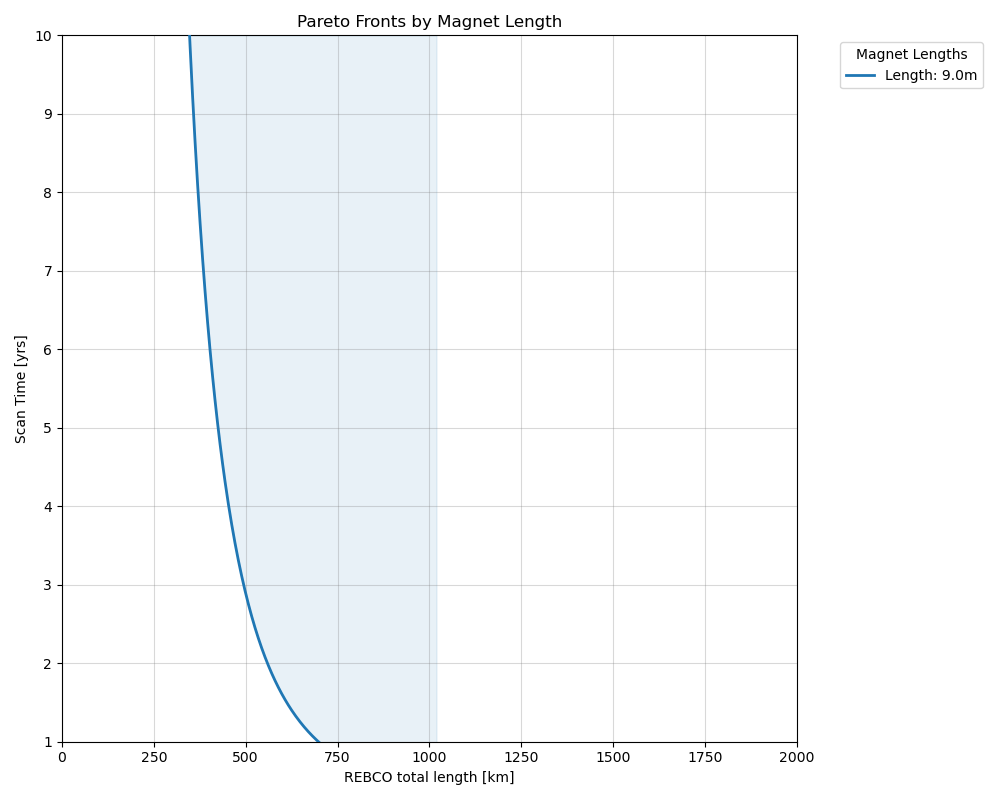

In [293]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import os
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

# Define candidate functions for the Pareto front trade-off
def power_law(x, a, b, c):
    x_safe = np.maximum(x, 1e-5)
    return a * (x_safe ** -b) + c

def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

# Find all CSV files that match your naming pattern
file_list = glob.glob('thickness_grids_L*.csv')

fig1, ax1 = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10.colors

all_pareto_points = []
all_fit_equations = []  
legend_items = []

for i, file_path in enumerate(file_list):
    df_all = pd.read_csv(file_path)
    
    if 'solenoid_length_m' in df_all.columns:
        length_val = df_all['solenoid_length_m'].iloc[0]
        label_name = f'Length: {length_val}m'
    else:
        length_val = os.path.basename(file_path)
        label_name = length_val

    df_filtered = df_all[(df_all['scan'] >= 0.95) & (df_all['scan'] <= 11.0)].reset_index(drop=True)
    
    if len(df_filtered) == 0:
        continue

    df_sorted = df_filtered.sort_values(by=['length_sc_km', 'scan'])

    pareto_x = []
    pareto_y = []
    min_y = float('inf')

    # Identify the non-dominated points
    for index, row in df_sorted.iterrows():
        if row['scan'] < min_y:
            pareto_x.append(row['length_sc_km'])
            pareto_y.append(row['scan'])
            min_y = row['scan']

    if not pareto_x:
        continue

    # Save the exact coordinates to our master list
    for px, py in zip(pareto_x, pareto_y):
        all_pareto_points.append({
            'source_file': os.path.basename(file_path), 
            'solenoid_length_m': length_val, 
            'length_sc_km': px, 
            'scan': py
        })

    line_color = colors[i % len(colors)]

    px_arr = np.array(pareto_x)
    py_arr = np.array(pareto_y)
    
    px_unique, idx = np.unique(px_arr, return_index=True)
    py_unique = py_arr[idx]

    line = None
    best_fit_y = None
    best_name = ""
    y_smooth = None
    
    # We need at least 3 points to fit a function with 3 parameters (a, b, c)
    if len(px_unique) >= 3:
        x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
        
        best_error = float('inf')
        best_params = []
        
        candidate_funcs = [
            (power_law, "Power Law"),
            (exponential_decay, "Exponential")
        ]
        
        for func, name in candidate_funcs:
            try:
                # Provide an initial guess to help the optimizer converge rapidly
                p0 = [py_unique.max(), 0.1, py_unique.min()]
                popt, _ = curve_fit(func, px_unique, py_unique, p0=p0, maxfev=10000)
                
                # Calculate the sum of squared residuals to evaluate fit quality
                residuals = py_unique - func(px_unique, *popt)
                ssr = np.sum(residuals**2)
                
                if ssr < best_error:
                    best_error = ssr
                    best_fit_y = func(x_smooth, *popt)
                    best_name = name
                    best_params = popt
            except Exception:
                continue
        
        if best_fit_y is not None:
            # Plot for the main aggregate figure
            line = ax1.plot(x_smooth, best_fit_y, color=line_color, linewidth=2, label=label_name, zorder=3)[0]
            ax1.fill_between(x_smooth, best_fit_y, y2=10.0, color=line_color, alpha=0.1, zorder=1)
            
            all_fit_equations.append({
                'solenoid_length_m': length_val,
                'function_type': best_name,
                'param_a': best_params[0],
                'param_b': best_params[1],
                'param_c': best_params[2],
                'sum_squared_error': best_error
            })
        else:
            # Fallback to PchipInterpolator if curve fitting fails
            spline = PchipInterpolator(px_unique, py_unique)
            y_smooth = spline(x_smooth)
            line = ax1.plot(x_smooth, y_smooth, color=line_color, linewidth=2, label=label_name + " (spline)", zorder=3)[0]
            ax1.fill_between(x_smooth, y_smooth, y2=10.0, color=line_color, alpha=0.1, zorder=1)
            
    elif len(px_unique) == 2:
        # Fallback to a standard spline if there are only 2 points
        x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
        spline = PchipInterpolator(px_unique, py_unique)
        y_smooth = spline(x_smooth)
        line = ax1.plot(x_smooth, y_smooth, color=line_color, linewidth=2, label=label_name, zorder=3)[0]
        ax1.fill_between(x_smooth, y_smooth, y2=10.0, color=line_color, alpha=0.1, zorder=1)

    # -------------------------------------------------------------------------
    # Create the individual plot for this specific dataset
    # -------------------------------------------------------------------------
    if len(px_unique) >= 2:
        fig_ind, ax_ind = plt.subplots(figsize=(8, 6))
        
        # Plot the exact points as a scatter plot
        ax_ind.scatter(px_unique, py_unique, color='black', label='Pareto Points', zorder=4)
        
        # Plot the best fit line (or fallback spline)
        if best_fit_y is not None:
            ax_ind.plot(x_smooth, best_fit_y, color=line_color, linewidth=2, label=f'Fit: {best_name}', zorder=3)
        elif y_smooth is not None:
            ax_ind.plot(x_smooth, y_smooth, color=line_color, linewidth=2, label='Fit: Spline (Fallback)', zorder=3)
            
        ax_ind.set_xlabel('REBCO total length [km]')
        ax_ind.set_ylabel('Scan Time [yrs]')
        ax_ind.set_title(f'Pareto Front and Fit - {label_name}')
        ax_ind.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
        ax_ind.legend()
        fig_ind.tight_layout()
        
        # Save and close to free up memory
        safe_filename = str(length_val).replace('.', '_').replace('/', '_')
        plt.savefig(f'individual_fit_{safe_filename}.png')
        plt.close(fig_ind)
    # -------------------------------------------------------------------------

    if line is not None:
        try:
            sort_value = float(length_val)
        except ValueError:
            sort_value = float('inf')
            
        legend_items.append((line, label_name, sort_value))


if all_pareto_points:
    df_saved = pd.DataFrame(all_pareto_points)
    df_saved.to_csv('saved_pareto_fronts.csv', index=False)
    print("Exact Pareto points saved successfully to 'saved_pareto_fronts.csv'")
    
    if all_fit_equations:
        df_eqs = pd.DataFrame(all_fit_equations)
        df_eqs.to_csv('saved_pareto_equations.csv', index=False)
        print("Mathematical fit parameters saved successfully to 'saved_pareto_equations.csv'")
else:
    print("No Pareto points were generated to save.")

print("Individual plots have been saved as PNG files in the current directory.")

# Sort the collected legend items based on the numeric length
legend_items.sort(key=lambda x: x[2])

# Unpack the sorted items into two separate lists for the main aggregate legend
sorted_handles = [item[0] for item in legend_items]
sorted_labels = [item[1] for item in legend_items]

ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(0, 2000)
ax1.set_ylim(1.0, 10.0)
ax1.set_title('Pareto Fronts by Magnet Length')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)

ax1.legend(sorted_handles, sorted_labels, title='Magnet Lengths', bbox_to_anchor=(1.05, 1), loc='upper left')

fig1.tight_layout()
plt.show()

In [ ]:
import importlib
import math
import solenoid_lib


importlib.reload(solenoid_lib)


from solenoid_lib import scan_time, dB_to_eta

# Magnet / bore geometry
B0_baseline = 18          # T
l_bore      = 8.5         # m
d_bore      = 0.090       # m
V_m3        = math.pi * (d_bore / 2)**2 * l_bore   # bore volume [m^3]
print(f"Bore volume: {V_m3:.4f} m^3")

s_per_year = 365.25 * 24 * 3600


print(f"{'Scenario':<40} {'Expected':>10}  {'DFSZ':>10} {'Ratio':>10}")
print("-" * 74)

scenarios = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q'),
    (B0_baseline, V_m3, 20e6, -20, 2.24,  'CORE-GUT')
]

for (B0, V_m3, Q, eta_dB, expected, name) in scenarios:
    eta_A  = dB_to_eta(eta_dB)
    t_dfsz = scan_time(B0, V_m3, Q=Q, eta_A=eta_A, model='DFSZ')
    ratio  = expected / t_dfsz
    print(f"{name:<40} {expected:>10.1f} {t_dfsz:>10.2f} {ratio:>10.3f}")